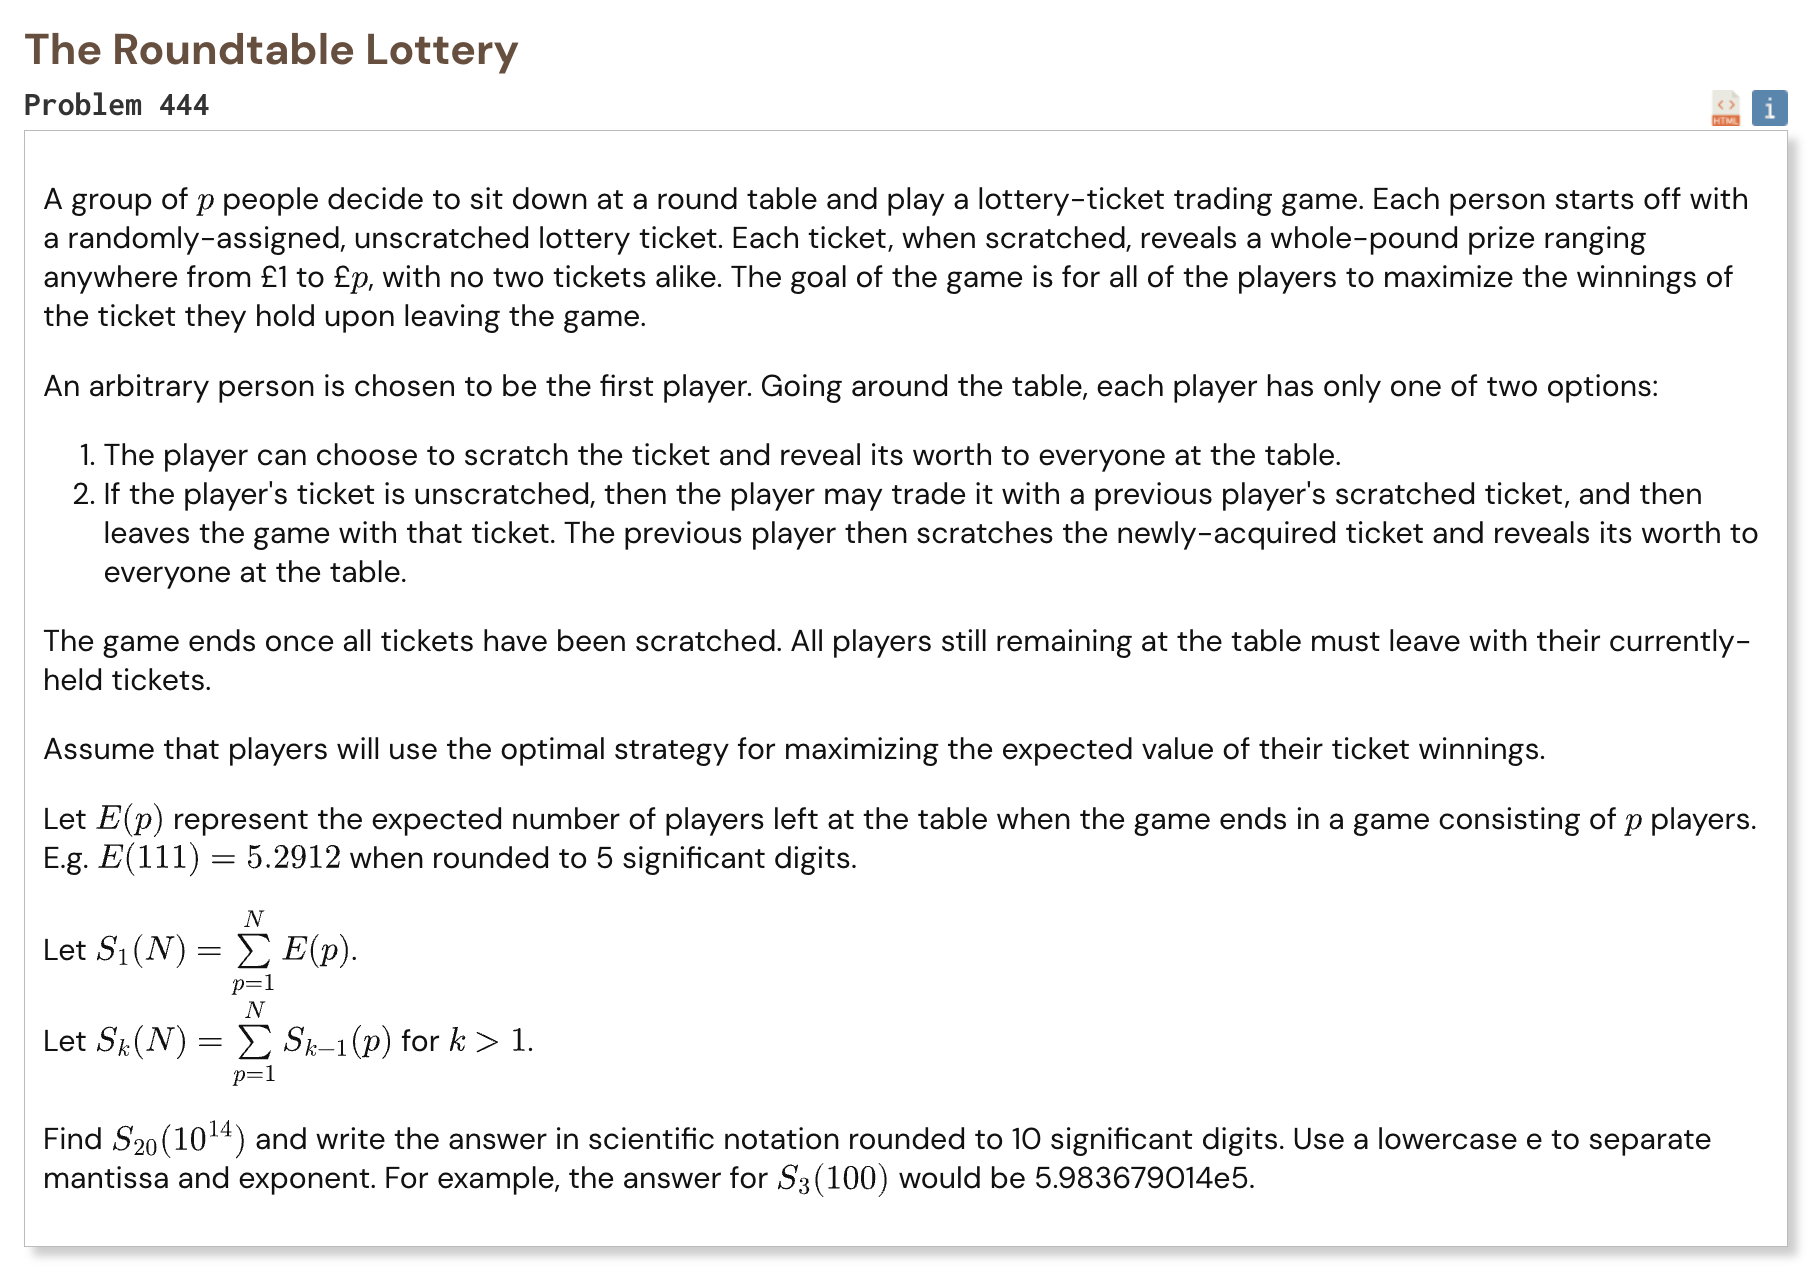

## Initial approach

-   the players who remain at the end correspond to record values in a random permutation
-   the probability that the ticket at position `i` is a new record is `1 / i`
-   therefore the expected number of remaining players is the harmonic number `H_p`
-   repeated summation has a closed form, so we do not need to calculate every value up to `10^14`
-   use the identity `S_k(N) = C(N+k, k) * (H_(N+k) - H_k)`
-   calculate the small harmonic number `H_20` directly
-   approximate the huge harmonic number with its high precision asymptotic expansion
-   use decimal for enough precision before formatting the result to 10 significant digits

In [1]:
%%time

from decimal import Decimal, getcontext
from math import comb

getcontext().prec = 80

N = 10**14
k = 20

gamma = Decimal(
    "0.57721566490153286060651209008240243104215933593992"
)

Hk = sum(
    (Decimal(1) / Decimal(i) for i in range(1, k + 1)),
    Decimal(0)
)

n = Decimal(N + k)

Hn = (
    n.ln()
    + gamma
    + Decimal(1) / (2 * n)
    - Decimal(1) / (12 * n**2)
    + Decimal(1) / (120 * n**4)
)

result = Decimal(comb(N + k, k)) * (Hn - Hk)

result = format(result, ".9e").replace("E", "e").replace("e+", "e")

print("Result:", result)

Result: 1.200856722e263
CPU times: user 304 μs, sys: 75 μs, total: 379 μs
Wall time: 392 μs
